# Viewing the AXI4-Stream Timing

In this demo, you will see:

- How to generate a VCD file with traces of signals
- Load the VCD and parse the VCD file in python with Waveflow's `VcdParser` utility
- Extract signals for **AXI4-Stream interface**
- Extract individual AXI4-Stream **bursts** from the parsed stream
- Deserialize the data in the burst into Waveflow data schemas and arrays for analysis
- Plot the bursts with a Waveflow **TimingDiagram**

## Pre-Requisites

Prior to running this notebook, you should run the demo:

```bash
python -m examples.stream_inband.poly_build --through validate_timing
```

This command will run the C-simulation, C synthesis and RTL co-simulation.  The RTL co-simulation is run with tracing so that the signals are captured for viewing.  We also import the following packages.

In [ ]:
from waveflow.hw.arrayutils import read_array
from poly import Float32, PolyCmdHdr, PolyRespHdr


## Generating a VCD file

The Vitis C simulation does not generally produce a timing waveform that can be easily read into python.  So, we re-run the simulation with the following command to capture a VCD file.  

```bash
xsim_vcd --top poly --comp waveflow_poly_proj --out dump.vcd
```

You can run this command at the command window.   Running the script will produce a VCD file in `vcd/dump.vcd`.  We can load this VCD file with the package `vcdvcd` package as follows

In [ ]:
import os
from vcdvcd import VCDVCD

vcd_file = 'dump.vcd'
fn = os.path.join(os.getcwd(), 'vcd', vcd_file)
if not os.path.exists(fn):
    raise FileNotFoundError(f"VCD file not found: {fn}")

# Parse the VCD file
vcd = VCDVCD(fn, signals=None, store_tvs=True)


It is useful to display the signals.  In this case, there are a large number of signals since we have captured every signal in the simulation.  

We also print the signals with the name `TDATA`. 

In [6]:
nsig = len(vcd.signals)
print(f"Number of signals in VCD: {nsig}")

# Find the signals with TDATA and TREADY in their names
tdatas = [s for s in vcd.signals if 'TDATA' in s]
print(tdatas)


Number of signals in VCD: 1131
['apatb_poly_top.in_stream_TDATA[31:0]', 'apatb_poly_top.out_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA_blk_n', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA_blk_n', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_47_1_fu_258_out_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA_reg[31:0]', 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA_int_regslice[31:0]', 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA_int_regslice[31:0]', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_346_1_fu_239.in_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_346_1_fu_239.in_stream_TDATA_blk_n', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_47_1_fu_258.in_stream_TDATA[31:0]', 'apatb_poly_top.AESL_inst_poly.grp_poly_Pipeline_VITIS_LOOP_47_1_fu_258.out_strea

In [7]:
from waveflow.utils.vcd import VcdParser
from waveflow.utils.timing import TimingDiagram

## Extracing the Signals for the AXI4-Stream

The above print out of the signals shows two relevant signals for the AXI4-Stream:

- `apatb_poly_top.AESL_inst_poly.in_stream_TDATA[31:0]`
- `apatb_poly_top.AESL_inst_poly.out_stream_TDATA[31:0]`

The signals are the data signals for the input and output streams of the Vitis kernel `poly`.  We can extract these signals and the clock as follows:


In [ ]:
# Create a parsing class
vp = VcdParser(vcd)

# Get the clock signal name
clk_name = vp.add_clock_signal()

top_name = 'AESL_inst_poly'
in_stream_name = f"{top_name}.in_stream_"
out_stream_name = f"{top_name}.out_stream_"

# Get the  AXI-Stream command signals
in_str_sigs, in_bw = vp.add_axiss_signals(name=in_stream_name, short_name_prefix='in_stream',
                                           ignore_multiple=True)
print(in_str_sigs)

# Get the output AXI-Stream signals
out_str_sigs, out_bw = vp.add_axiss_signals(name=out_stream_name, short_name_prefix='out_stream',
                                            ignore_multiple=True)
print(out_str_sigs)


{'tdata': 'apatb_poly_top.AESL_inst_poly.in_stream_TDATA[31:0]', 'tvalid': 'apatb_poly_top.AESL_inst_poly.in_stream_TVALID', 'tready': 'apatb_poly_top.AESL_inst_poly.in_stream_TREADY', 'tlast': 'apatb_poly_top.AESL_inst_poly.in_stream_TLAST[0:0]'}
{'tdata': 'apatb_poly_top.AESL_inst_poly.out_stream_TDATA[31:0]', 'tvalid': 'apatb_poly_top.AESL_inst_poly.out_stream_TVALID', 'tready': 'apatb_poly_top.AESL_inst_poly.out_stream_TREADY', 'tlast': 'apatb_poly_top.AESL_inst_poly.out_stream_TLAST[0:0]'}


## Creating a Timing Diagram

We can now create a timing diagram from the parsed signals as follows.  

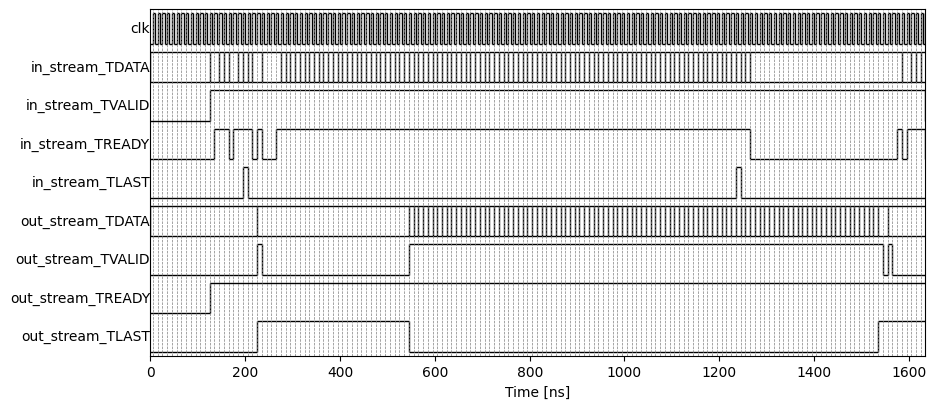

In [9]:
# Get the timing signals
sig_list = vp.get_td_signals()

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

## Getting the Burst Timing and Deserializing the Burst Data

The VCD parser has a method `extract_axis_bursts` that will extract the bursts in the stream.  We use this to print the bursts.  You will see that there are two bursts on the input, corresponding to the input command header and input data.  The output has three bursts corresponding to the response header, output data, and response footer.

In [11]:
# Extract the AXI-Stream bursts and print the burst information for the input
bursts_in, clk_period= vp.extract_axis_bursts(clk_name, in_str_sigs)
print('Input AXI-Stream bursts:')
for i, burst in enumerate(bursts_in):
    nbeats = len(burst['beat_type'])
    nbeats_transfer = sum(1 for bt in burst['beat_type'] if bt == 0)
    print(f"Burst {i}: tstart = {burst['tstart']}, bt={burst['beat_type']}, nbeats_transfer = {nbeats_transfer}")

# Extract the AXI-Stream output bursts
print('\nOutput AXI-Stream bursts:')
bursts_out, clk_period= vp.extract_axis_bursts(clk_name, out_str_sigs)
for i, burst in enumerate(bursts_out):
    nbeats = len(burst['beat_type'])
    nbeats_transfer = sum(1 for bt in burst['beat_type'] if bt == 0)
    print(f"Burst {i}: tstart = {burst['tstart']}, bt={burst['beat_type']}, nbeats_transfer = {nbeats_transfer}")


Input AXI-Stream bursts:
Burst 0: tstart = 135.0, bt=[0, 0, 0, 2, 0, 0, 0], nbeats_transfer = 6
Burst 1: tstart = 205.0, bt=[0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], nbeats_transfer = 100

Output AXI-Stream bursts:
Burst 0: tstart = 225.0, bt=[0], nbeats_transfer = 1
Burst 1: tstart = 545.0, bt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], nbeats_transfer = 100
Burst 2: tstart = 1555.0, bt=[0], nbeats_transfer = 1


We can also extract the values by deserializing the captured information on the bursts.

In [ ]:

word_bw = 32
cmd_hdr = PolyCmdHdr()
nwords = PolyCmdHdr.nwords_per_inst(word_bw=word_bw)

words = bursts_in[0]['data']
cmd_hdr.deserialize(word_bw=word_bw, packed=words)
print("PolyCmdHdr (DATA) values:")
for k, v in cmd_hdr.val.items():
    print(f"    {k}: {v}")
    
print("\nInput sample data values, x")
nsamp = cmd_hdr.val['nsamp']
x = read_array(packed=bursts_in[1]['data'], word_bw=word_bw, elem_type=Float32, shape=(nsamp,))
print(x)

resp_hdr = PolyRespHdr()
words = bursts_out[0]['data']
resp_hdr.deserialize(word_bw=word_bw, packed=words)
print("\nPolyRespHdr values:")
for k, v in resp_hdr.val.items():
    print(f"    {k}: {v}")

print("\nOutput sample data values, y")
y = read_array(packed=bursts_out[1]['data'], word_bw=word_bw, elem_type=Float32, shape=(nsamp,))
print(y)



Finally, we replot the timing diagram with the bursts color coded so that you can see the timing.

In [ ]:
from matplotlib.patches import Patch

# Create the timing diagram
td = TimingDiagram()
td.add_signals(sig_list)
trange = None
ax = td.plot_signals(add_clk_grid=True, trange=trange, 
                text_scale_factor=1e4, text_mode='never')
_ = ax.set_xlabel('Time [ns]')

def color_burst(sig_name, burst, color, clk_period):
    t0 = burst['tstart']
    t1 = t0 + len(burst['beat_type']) * clk_period
    td.add_patch(sig_name=sig_name, time=[t0, t1], color=color, alpha=0.3)

hdr_color = 'orange'
data_color = 'green'
color_burst(sig_name='in_stream_TDATA', burst=bursts_in[0], 
            color=hdr_color, clk_period=clk_period)
color_burst(sig_name='in_stream_TDATA', burst=bursts_in[1], 
            color=data_color, clk_period=clk_period)

color_burst(sig_name='out_stream_TDATA', burst=bursts_out[0], 
            color=hdr_color, clk_period=clk_period)
color_burst(sig_name='out_stream_TDATA', burst=bursts_out[1], 
            color=data_color, clk_period=clk_period)

legend_elements = [
    Patch(facecolor='orange', edgecolor='black', alpha=0.3, label='header'),
    Patch(facecolor='green', edgecolor='black', alpha=0.3, label='data'),
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

